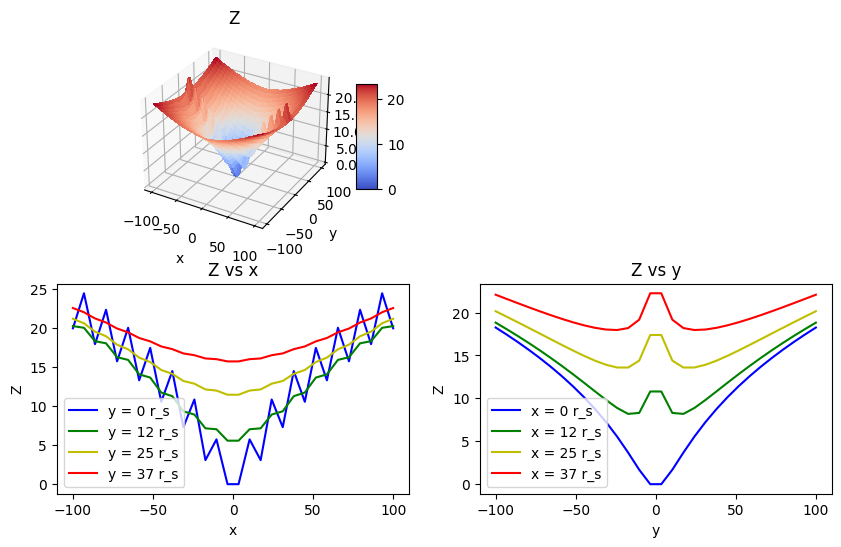

" CHECK COMPLETE\n# r\nplot_3d_and_slice(r, 'r')\n\n# boundary conditions\nprint(left_boundary)\nprint(right_boundary)\n\n# shape of z\nprint(f'\nz.shape = {z.shape}\n')\n\n# values around the boundaries\nprint(f'z[:10, 0] = {z[:10, 0]}')\nprint(f'z[:10, 1] = {z[:10, 1]}')\nprint(f'z[:10, 2] = {z[:10, 2]}')\nprint(f'z[:10, 3] = {z[:10, 3]}')\nprint()\nprint(f'z[:10, -4] = {z[:10, -4]}')\nprint(f'z[:10, -3] = {z[:10, -3]}')\nprint(f'z[:10, -2] = {z[:10, -2]}')\nprint(f'z[:10, -1] = {z[:10, -1]}')\n"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

### Metric
def g_xx(x, y):
    x1 = x - x0
    x2 = x + x0
    r1 = np.sqrt(x1**2 + y**2)
    r2 = np.sqrt(x2**2 + y**2)
    return 1 + GM * (x1**2 / r1**3 + x2**2 / r2**3)
def g_xy(x, y):
    x1 = x - x0
    x2 = x + x0
    r1 = np.sqrt(x1**2 + y**2)
    r2 = np.sqrt(x2**2 + y**2)
    return GM * (x1*y / r1**3 + x2*y / r2**3)
def g_yy(x, y):
    x1 = x - x0
    x2 = x + x0
    r1 = np.sqrt(x1**2 + y**2)
    r2 = np.sqrt(x2**2 + y**2)
    return 1 + GM * (y**2 / r1**3 + y**2 / r2**3)

### values for the system
GM = 1
x0 = 10
n_steps = 30 # must be even 

### Discretize the metric
# values
x_start, x_end = -100, 100
y_start, y_end = -100, 100
delta_x = (x_end - x_start) / (n_steps - 1)
delta_y = (y_end - y_start) / (n_steps - 1)
# create the grid
x_axis = np.linspace(x_start, x_end, n_steps)
y_axis = np.linspace(y_start, y_end, n_steps)
x_meshed, y_meshed = np.meshgrid(x_axis, y_axis)
r = np.sqrt(x_meshed**2 + y_meshed**2)
# discretize the metric
g_xx_discretized = g_xx(x_meshed, y_meshed)
g_xy_discretized = g_xy(x_meshed, y_meshed)
g_yy_discretized = g_yy(x_meshed, y_meshed)

### Evaluate Z(x,y)
# initialize Z
z = np.zeros_like(x_meshed)
# evaluate the boundary condition
left_boundary = 2 * np.sqrt(r[0] - GM)
right_boundary = 2 * np.sqrt(r[-1] - GM)
# set the boundary conditions
z[:, 0] = left_boundary    # for odd  points
z[:, -1] = right_boundary  # for even points
# evaluate z(x,y)
for y in range(n_steps): # even indeces
    for x in range(2, n_steps, 2):
        '''SIGNS NOT ACCURATE'''
        signx = np.where(x_meshed[:,x] >= 0, 1, -1)

        z[:, x] = signx * 2 * delta_x * np.sqrt(g_xx_discretized[:,x-1] - 1) + z[:,x-2]
for y in range(n_steps): # odd indeces
    for x in range(n_steps-3, 0, -2):
        '''SIGNS NOT ACCURATE'''
        signx = np.where(x_meshed[:,x] >= 0, 1, -1)
        
        z[:, x] = -signx * 2 * delta_x * np.sqrt(g_xx_discretized[:,x+1] - 1) + z[:,x+2]


### Plots
# the function
def plot_3d_and_slice(surface, surface_name):
    num_slices = 4

    fig= plt.figure(figsize=(10, 6))
    ax_3d = fig.add_subplot(221, projection='3d')
    ax_slicex = fig.add_subplot(223)
    ax_slicey = fig.add_subplot(224)

    # from matplotlib example (modified)
    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax_3d.zaxis.set_major_formatter('{x:.02f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)
    # ax_3d.set_zlim(bottom=0)

    color = ['b', 'g', 'y' , 'r']
    while len(color) < num_slices:
        color.append['r']
    
    for i in range(num_slices):
         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)} r_s')
         ax_slicex.set(xlabel='x', ylabel=surface_name, title=f'{surface_name} vs x')
         ax_slicey.plot(y_axis, surface[:,int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'x = {int(100*i/2/num_slices)} r_s')
         ax_slicey.set(xlabel='y', ylabel=surface_name, title=f'{surface_name} vs y')
    ax_slicex.legend()
    ax_slicey.legend()
    
    plt.tight_layout
    plt.show()
    return None
'''
# plot the metric
plot_3d_and_slice(g_xx_discretized, 'g_xx')
plot_3d_and_slice(g_xy_discretized, 'g_xy')
plot_3d_and_slice(g_yy_discretized, 'g_yy')
'''
# plot Z
plot_3d_and_slice(z, 'Z')


### Value Checks
''' CHECK COMPLETE
# r
plot_3d_and_slice(r, 'r')

# boundary conditions
print(left_boundary)
print(right_boundary)

# shape of z
print(f'\nz.shape = {z.shape}\n')

# values around the boundaries
print(f'z[:10, 0] = {z[:10, 0]}')
print(f'z[:10, 1] = {z[:10, 1]}')
print(f'z[:10, 2] = {z[:10, 2]}')
print(f'z[:10, 3] = {z[:10, 3]}')
print()
print(f'z[:10, -4] = {z[:10, -4]}')
print(f'z[:10, -3] = {z[:10, -3]}')
print(f'z[:10, -2] = {z[:10, -2]}')
print(f'z[:10, -1] = {z[:10, -1]}')
'''